In [2]:
# -*- coding: utf-8 -*-

# Proyecto: Mining Supply Chain Decision Intelligence

# Notebook 03 - Supervisado: Predicción de stockout próximo

Versión sincronizada con Google Drive.

### Objetivo
--------
Entrenar un modelo supervisado que anticipe el riesgo de quiebre de stock
para el próximo día por combinación mina-item.

### ¿Por qué este target?
---------------------
- Es accionable: ayuda a decidir reposición antes de que ocurra el problema.
- Es útil para negocio: un stockout en minería remota tiene alto costo operativo.
- Es compatible con el dashboard y con la futura capa de refuerzo.

### El notebook incluye:
- carga de datos procesados,
- creación de target temporal,
- separación temporal train/validation/test,
- pipeline de preprocesamiento,
- comparación de varios modelos,
- ajuste de umbral,
- evaluación final,
- explicación básica con importancias,
- exportación del mejor modelo y dataset de scoring.

### Buenas prácticas aplicadas
--------------------------
- Sin leakage temporal.
- Separación por fechas.
- Pipeline de entrenamiento reproducible.
- Validación con métricas de clasificación orientadas a negocio.
- Guardado explícito de artefactos.

Desarrollado y pensado para ejecutarse en Google Colab.

In [3]:
# =========================================================
# 1) Imports.
# =========================================================

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import warnings
from typing import Dict, List, Tuple

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

In [5]:
# =========================================================
# 2) Definir rutas compartidas.
# =========================================================

# Detectael directorio actual de ejecucion.
CURRENT_DIR = Path.cwd()

# Define la raiz del proyecto.
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_DIR / "models"
ASSETS_DIR = PROJECT_DIR / "assets"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"

# Crea los directorios si no existen.
for folder in [PROJECT_DIR,
               DATA_DIR,
               RAW_DIR,
               PROCESSED_DIR,
               MODELS_DIR,
               ASSETS_DIR,
               NOTEBOOKS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Proyecto configurado localmente en:", PROJECT_DIR)
print(f"PROCESSED_DIR:", PROCESSED_DIR)
print(f"MODELS_DIR;", MODELS_DIR)

Proyecto configurado localmente en: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence
PROCESSED_DIR: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\processed
MODELS_DIR; c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\models


In [6]:
# =========================================================
# 3) Configuración global.
# =========================================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use("default")
sns.set_theme(style="whitegrid")

TARGET_NAME = "next_day_stockout"
HOLDOUT_FRACTION = 0.20
VALIDATION_FRACTION_WITHIN_DEV = 0.20

In [7]:
# =========================================================
# 4) Utilidades generales.
# =========================================================

def print_section(title: str) -> None:
    """
    Imprime un separador visual para ordenar la salida del notebook.
    """
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def load_dataset(path: Path) -> pd.DataFrame:
    """
    Carga un CSV desde Drive con parsing de fechas.
    """
    if not path.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo: {path}. Ejecutá primero el Notebook 02."
        )
    return pd.read_csv(path, parse_dates=["date"])

def create_next_day_target(df: pd.DataFrame, group_cols: List[str], source_col: str = "is_stockout") -> pd.DataFrame:
    """
    Crea el target de stockout del proximo dia por serie.
    Esto evita leakage temporal, porque el modelo aprende a anticipar el riesgo
    del dia siguiente usando informacion disponible hoy.
    """
    out = df.copy().sort_values(group_cols + ["date"]).reset_index(drop=True)
    out[TARGET_NAME] = out.groupby(group_cols, sort=False)[source_col].shift(-1)
    return out

def split_time_based(df: pd.DataFrame, date_col: str = "date") -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Hace una separacion temporal train/validation/test respetando el orden de tiempo.
    """
    dates = np.array(sorted(df[date_col].unique()))
    if len(dates) < 10:
        raise ValueError("No hay suficientes fechas para hacer un split temporal razonable.")

    test_start_idx = int(len(dates) * (1 - HOLDOUT_FRACTION))
    test_start_date = dates[test_start_idx]

    dev_df = df[df[date_col] < test_start_date].copy()
    test_df = df[df[date_col] >= test_start_date].copy()

    dev_dates = np.array(sorted(dev_df[date_col].unique()))
    val_start_idx = int(len(dev_dates) * (1 - VALIDATION_FRACTION_WITHIN_DEV))
    val_start_date = dev_dates[val_start_idx]

    train_df = dev_df[dev_df[date_col] < val_start_date].copy()
    val_df = dev_df[dev_df[date_col] >= val_start_date].copy()

    return train_df, val_df, test_df

def choose_threshold(y_true: pd.Series, y_proba: np.ndarray, beta: float = 2.0) -> Tuple[float, pd.DataFrame]:
    """
    Elige el umbral que maximiza F-beta en validacion.
    Beta > 1 favorece recall, que en este proyecto tiene sentido porque
    perder un stockout es mas caro que disparar algunas alertas de mas.
    """
    thresholds = np.linspace(0.05, 0.95, 91)
    rows = []
    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        rows.append({
            "threshold": thr,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=beta, zero_division=0),
        })

    results = pd.DataFrame(rows)
    best_row = results.sort_values(["f2", "recall", "precision"], ascending=False).iloc[0]
    return float(best_row["threshold"]), results

def evaluate_classifier(y_true: pd.Series, y_proba: np.ndarray, threshold: float) -> Dict[str, float]:
    """
    Calcula metricas de negocio y metricas estadisticas del modelo.
    """
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "brier": brier_score_loss(y_true, y_proba),
    }

def build_preprocessor(numeric_features: List[str], categorical_features: List[str]) -> ColumnTransformer:
    """
    Construye el preprocesamiento para variables numericas y categoricas.
    """
    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor

def get_feature_names(preprocessor: ColumnTransformer) -> List[str]:
    """
    Recupera nombres de features luego de la transformacion.
    """
    return list(preprocessor.get_feature_names_out())

In [8]:
# =========================================================
# 5) Carga del dataset procesado y creacion del target.
# =========================================================

print_section("1. Carga y target temporal")

full_path = PROCESSED_DIR / "feature_engineered_dataset.csv"
df = load_dataset(full_path)
print(f"Dataset cargado: {df.shape}")

# Creamos el target de forma temporalmente consistente.
df = create_next_day_target(df, group_cols=["mine_id", "item_id"], source_col="is_stockout")

# Eliminamos filas sin target por ser el ultimo dia de cada serie.
df = df.dropna(subset=[TARGET_NAME]).copy()
df[TARGET_NAME] = df[TARGET_NAME].astype(int)

print(f"Dataset con target: {df.shape}")
print(df[["date", "mine_id", "item_id", "is_stockout", TARGET_NAME]].head(10).to_string(index=False))

print("\nDistribución del target:")
print(df[TARGET_NAME].value_counts(normalize=True).rename("proportion").to_string())


1. Carga y target temporal
Dataset cargado: (35088, 104)
Dataset con target: (35040, 105)
      date mine_id item_id  is_stockout  next_day_stockout
2024-01-01     M01     I01            0                  0
2024-01-02     M01     I01            0                  0
2024-01-03     M01     I01            0                  0
2024-01-04     M01     I01            0                  0
2024-01-05     M01     I01            0                  0
2024-01-06     M01     I01            0                  0
2024-01-07     M01     I01            0                  0
2024-01-08     M01     I01            0                  0
2024-01-09     M01     I01            0                  0
2024-01-10     M01     I01            0                  0

Distribución del target:
next_day_stockout
0    0.993636
1    0.006364


In [9]:
# =========================================================
# 6) Separacion temporal train / validation / test.
# =========================================================

print_section("2. Split temporal")

train_df, val_df, test_df = split_time_based(df, date_col="date")

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train date range: {train_df['date'].min()} -> {train_df['date'].max()}")
print(f"Validation date range: {val_df['date'].min()} -> {val_df['date'].max()}")
print(f"Test date range: {test_df['date'].min()} -> {test_df['date'].max()}")


2. Split temporal
Train shape: (22416, 105)
Validation shape: (5616, 105)
Test shape: (7008, 105)
Train date range: 2024-01-01 00:00:00 -> 2025-04-11 00:00:00
Validation date range: 2025-04-12 00:00:00 -> 2025-08-06 00:00:00
Test date range: 2025-08-07 00:00:00 -> 2025-12-30 00:00:00


In [10]:
# =========================================================
# 7) Definicion de features.
# =========================================================

print_section("3. Definicion de features")

# Columnas que no deben entrar como features por ser identificadores o leakage directo.
leakage_cols = {
    "date",
    TARGET_NAME,
    "mine_name",
    "item_name",
    "supplier_name",
}

# Variables de negocio que se calculan mirando toda la base y, por tanto,
# no deben usarse para entrenar un modelo temporal realista.
future_leakage_cols = {
    "mine_total_cost",
    "mine_avg_service",
    "mine_stockout_rate",
    "mine_avg_risk",
    "mine_avg_demand",
    "mine_avg_distance",
    "item_total_cost",
    "item_avg_service",
    "item_stockout_rate",
    "item_avg_risk",
    "item_avg_demand",
    "supplier_total_cost",
    "supplier_avg_service",
    "supplier_stockout_rate",
    "supplier_avg_lead_orders",
    "mine_cost_rank",
    "item_cost_rank",
    "supplier_cost_rank",
}

# Tambien evitamos usar variables que son el propio resultado operativo del dia,
# porque el target es el riesgo del dia siguiente.
highly_contemporaneous_cols = {
    "total_cost",
    "holding_cost",
    "stockout_cost",
    "transport_cost",
    "cost_per_unit_demand",
    "cost_per_unit_sold",
}

# Algunas variables son validas como historia del dia actual para anticipar el proximo dia.
# Dejamos fuera las que podrian funcionar como una copia directa del resultado.
exclude_cols = leakage_cols | future_leakage_cols | highly_contemporaneous_cols
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Categoricas y numericas.
categorical_features = [
    col for col in ["mine_id", "item_id", "supplier_id", "weather_state"] if col in feature_cols
]

numeric_features = [col for col in feature_cols if col not in categorical_features]

# Depuracion final para evitar que alguna columna sin sentido entre al modelo.
for col in ["day_of_week_label"]:
    if col in numeric_features:
        numeric_features.remove(col)
    if col in categorical_features:
        categorical_features.remove(col)

print(f"Features numericas: {len(numeric_features)}")
print(f"Features categoricas: {len(categorical_features)}")
print("\nPrimeras features numericas:")
print(numeric_features[:25])
print("\nFeatures categoricas:")
print(categorical_features)

X_train = train_df[numeric_features + categorical_features].copy()
y_train = train_df[TARGET_NAME].copy()
X_val = val_df[numeric_features + categorical_features].copy()
y_val = val_df[TARGET_NAME].copy()
X_test = test_df[numeric_features + categorical_features].copy()
y_test = test_df[TARGET_NAME].copy()


3. Definicion de features
Features numericas: 72
Features categoricas: 4

Primeras features numericas:
['altitude_m', 'distance_km', 'priority_level', 'unit_cost', 'holding_cost_factor', 'criticality', 'base_consumption', 'day_of_year', 'month', 'quarter', 'is_weekend', 'is_month_end', 'temperature_c', 'wind_speed_kmh', 'visibility_km', 'demand_units', 'initial_stock', 'stock_before_demand', 'received_units', 'sales_units', 'stockout_units', 'ending_stock', 'reorder_point', 'target_stock', 'order_qty']

Features categoricas:
['mine_id', 'item_id', 'supplier_id', 'weather_state']



4. Lectura inicial de negocio
Tasa de positivos (stockout proximo dia):
Train: 0.0065
Validation: 0.0053
Test: 0.0067


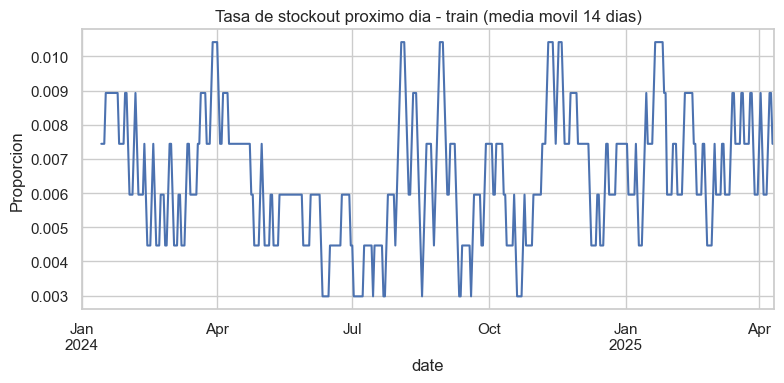

In [11]:
# =========================================================
# 8) EDA rapido sobre el target y variables criticas.
# =========================================================

print_section("4. Lectura inicial de negocio")

print("Tasa de positivos (stockout proximo dia):")
print(f"Train: {y_train.mean():.4f}")
print(f"Validation: {y_val.mean():.4f}")
print(f"Test: {y_test.mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
train_df.groupby("date")[TARGET_NAME].mean().rolling(14).mean().plot(ax=ax)
ax.set_title("Tasa de stockout proximo dia - train (media movil 14 dias)")
ax.set_ylabel("Proporcion")
plt.tight_layout()
plt.show()

In [12]:
# =========================================================
# 9) Preprocesamiento.
# =========================================================

print_section("5. Preprocesamiento")

preprocessor = build_preprocessor(numeric_features, categorical_features)


5. Preprocesamiento


In [13]:
# =========================================================
# 10) Modelos candidatos.
# =========================================================

print_section("6. Entrenamiento de modelos candidatos")

# Calculamos desbalance para XGBoost en caso de usarlo.
pos_rate = float(y_train.mean())
neg_rate = 1 - pos_rate
scale_pos_weight = (neg_rate / pos_rate) if pos_rate > 0 else 1.0

candidate_models = {
    "logistic_regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=300,
        max_depth=6,
        random_state=RANDOM_STATE,
    ),
}

if HAS_XGB:
    candidate_models["xgboost"] = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        min_child_weight=1,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )

results = []
pipelines: Dict[str, Pipeline] = {}
threshold_table = []

for name, model in candidate_models.items():
    print(f"\nEntrenando: {name}")
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train, y_train)
    val_proba = pipe.predict_proba(X_val)[:, 1]
    best_thr, thr_results = choose_threshold(y_val, val_proba, beta=2.0)
    metrics = evaluate_classifier(y_val, val_proba, best_thr)

    results.append({
        "model": name,
        **metrics,
        "best_threshold": best_thr,
    })
    threshold_table.append(thr_results.assign(model=name))
    pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(["pr_auc", "f2", "recall"], ascending=False).reset_index(drop=True)
threshold_df = pd.concat(threshold_table, ignore_index=True)

print("\nResumen de validacion:")
print(results_df.to_string(index=False))


6. Entrenamiento de modelos candidatos

Entrenando: logistic_regression

Entrenando: random_forest

Entrenando: hist_gradient_boosting


Exception in thread Thread-35 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\acer\anaconda3\envs\kaggle_ds\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\acer\anaconda3\envs\kaggle_ds\lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\acer\anaconda3\envs\kaggle_ds\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\acer\anaconda3\envs\kaggle_ds\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\acer\anaconda3\envs\kaggle_ds\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 105: invalid start byte



Entrenando: xgboost

Resumen de validacion:
                 model  roc_auc   pr_auc  precision   recall       f1       f2    brier  best_threshold
               xgboost 0.999051 0.838314   0.608696 0.933333 0.736842 0.843373 0.002804            0.36
   logistic_regression 0.999171 0.837523   0.576923 1.000000 0.731707 0.872093 0.003840            0.51
         random_forest 0.999123 0.833747   0.612245 1.000000 0.759494 0.887574 0.001912            0.30
hist_gradient_boosting 0.998920 0.815011   0.636364 0.933333 0.756757 0.853659 0.002615            0.23


In [14]:
# =========================================================
# 11) Seleccion del mejor modelo.
# =========================================================

print_section("7. Seleccion del mejor modelo")

best_row = results_df.iloc[0]
best_model_name = best_row["model"]
best_threshold = float(best_row["best_threshold"])
best_pipeline = pipelines[best_model_name]

print(f"Mejor modelo: {best_model_name}")
print(f"Umbral optimo en validacion: {best_threshold:.2f}")


7. Seleccion del mejor modelo
Mejor modelo: xgboost
Umbral optimo en validacion: 0.36


In [15]:
# =========================================================
# 12) Reentrenamiento con train + validation.
# =========================================================

print_section("8. Reentrenamiento final")

train_val_df = pd.concat([train_df, val_df], ignore_index=True)
X_train_val = train_val_df[numeric_features + categorical_features].copy()
y_train_val = train_val_df[TARGET_NAME].copy()

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", candidate_models[best_model_name]),
])
final_pipeline.fit(X_train_val, y_train_val)


8. Reentrenamiento final


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False



9. Evaluacion final en test
Metricas de test:
roc_auc: 0.9994
pr_auc: 0.9066
precision: 0.7843
recall: 0.8511
f1: 0.8163
f2: 0.8368
brier: 0.0019


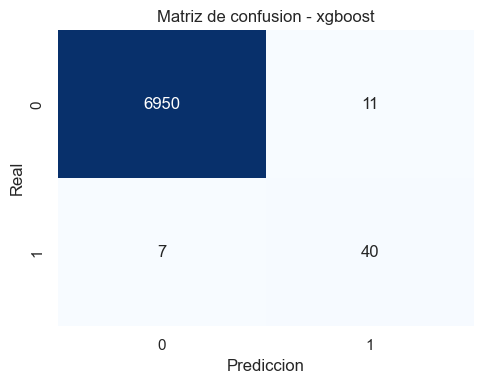

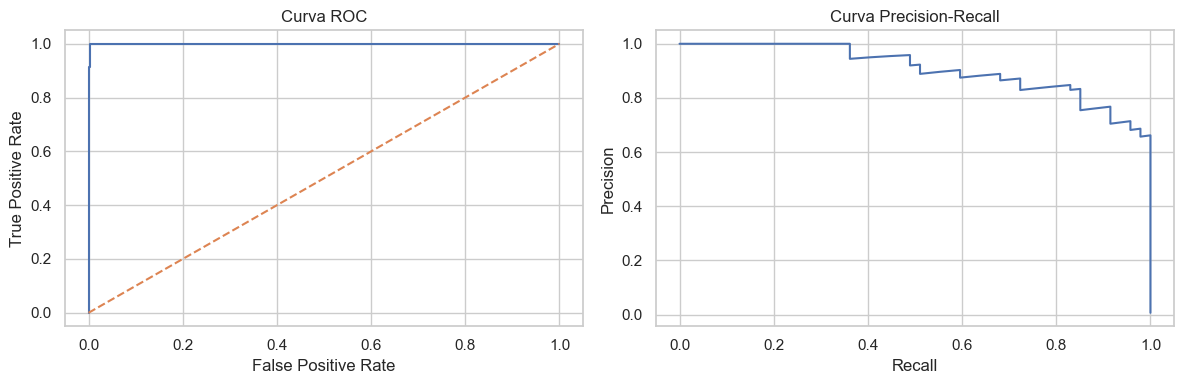

In [16]:
# =========================================================
# 13) Evaluacion final en test holdout.
# =========================================================

print_section("9. Evaluacion final en test")

test_proba = final_pipeline.predict_proba(X_test)[:, 1]
test_metrics = evaluate_classifier(y_test, test_proba, best_threshold)
test_pred = (test_proba >= best_threshold).astype(int)

print("Metricas de test:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Matriz de confusion - {best_model_name}")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, test_proba)
precision, recall, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr)
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("Curva ROC")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")

axes[1].plot(recall, precision)
axes[1].set_title("Curva Precision-Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

plt.tight_layout()
plt.show()


10. Importancia de variables


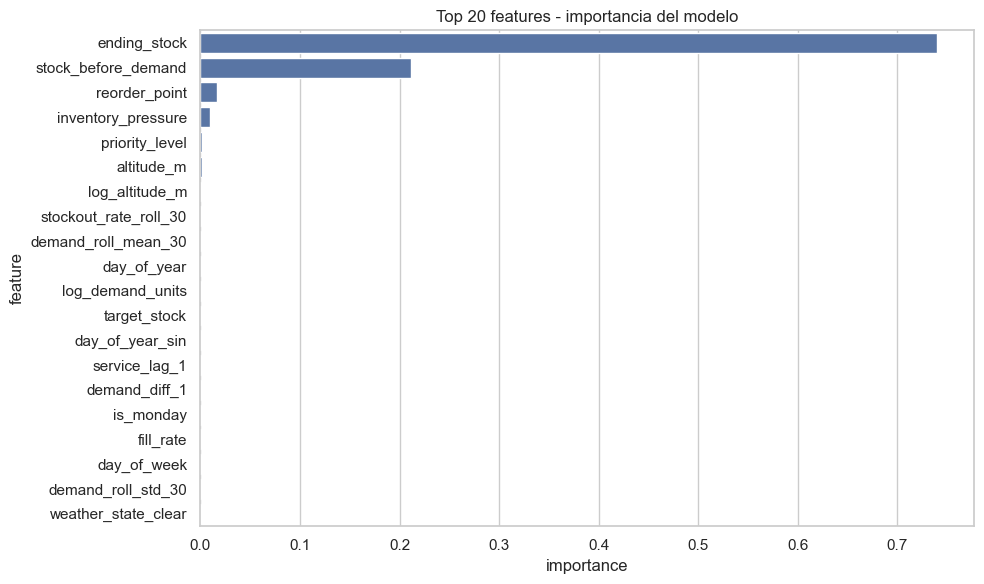


Top features:
              feature  importance
         ending_stock    0.740006
  stock_before_demand    0.211782
        reorder_point    0.016471
   inventory_pressure    0.009529
       priority_level    0.001807
           altitude_m    0.001140
       log_altitude_m    0.000902
stockout_rate_roll_30    0.000734
  demand_roll_mean_30    0.000680
          day_of_year    0.000610
     log_demand_units    0.000585
         target_stock    0.000567
      day_of_year_sin    0.000526
        service_lag_1    0.000510
        demand_diff_1    0.000489
            is_monday    0.000485
            fill_rate    0.000477
          day_of_week    0.000472
   demand_roll_std_30    0.000445
  weather_state_clear    0.000428


In [17]:
# =========================================================
# 14) Importancia de variables.
# =========================================================

print_section("10. Importancia de variables")

# Recuperamos nombres despues del preprocesamiento.
feature_names = get_feature_names(final_pipeline.named_steps["preprocessor"])
model = final_pipeline.named_steps["model"]

importance_df = None

if hasattr(model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(20), x="importance", y="feature")
    plt.title("Top 20 features - importancia del modelo")
    plt.tight_layout()
    plt.show()

elif hasattr(model, "coef_"):
    coef = model.coef_.ravel()
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(coef),
        "signed_coef": coef,
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(20), x="importance", y="feature")
    plt.title("Top 20 features - importancia absoluta")
    plt.tight_layout()
    plt.show()

else:
    # Fallback robusto: permutation importance sobre una muestra de test.
    sample_n = min(3000, len(X_test))
    sampled_X = X_test.sample(sample_n, random_state=RANDOM_STATE)
    sampled_y = y_test.loc[sampled_X.index]
    perm = permutation_importance(
        final_pipeline,
        sampled_X,
        sampled_y,
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring="average_precision",
    )
    importance_df = pd.DataFrame({
        "feature": sampled_X.columns,
        "importance": perm.importances_mean,
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(20), x="importance", y="feature")
    plt.title("Top 20 features - permutation importance")
    plt.tight_layout()
    plt.show()

print("\nTop features:")
print(importance_df.head(20).to_string(index=False))

In [18]:
# =========================================================
# 15) Scoring del dataset completo.
# =========================================================

print_section("11. Scoring del dataset completo")

# Reentrenamos sobre todo el dataset disponible con target no nulo para generar predicciones finales.
full_X = df[numeric_features + categorical_features].copy()
full_y = df[TARGET_NAME].copy()

final_full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", candidate_models[best_model_name]),
])
final_full_pipeline.fit(full_X, full_y)

full_proba = final_full_pipeline.predict_proba(full_X)[:, 1]
full_pred = (full_proba >= best_threshold).astype(int)

scoring_df = df[["date", "mine_id", "item_id", "supplier_id", "weather_state", TARGET_NAME]].copy()
scoring_df["predicted_stockout_proba_next_day"] = full_proba
scoring_df["predicted_stockout_flag_next_day"] = full_pred
scoring_df["decision_alert_level"] = pd.cut(
    scoring_df["predicted_stockout_proba_next_day"],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["low", "medium", "high"],
)

# Dataset util para dashboard / app.
scoring_path = PROCESSED_DIR / "model_scoring_dataset.csv"
scoring_df.to_csv(scoring_path, index=False)
print(f"Scoring dataset guardado en: {scoring_path}")


11. Scoring del dataset completo
Scoring dataset guardado en: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\processed\model_scoring_dataset.csv


In [19]:
# =========================================================
# 16) Exportacion de artefactos del modelo.
# =========================================================

print_section("12. Exportacion de artefactos")

model_artifact = {
    "model_name": best_model_name,
    "pipeline": final_full_pipeline,
    "threshold": best_threshold,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target_name": TARGET_NAME,
    "train_metrics": results_df.to_dict(orient="records"),
    "test_metrics": test_metrics,
}

model_path = MODELS_DIR / "stockout_next_day_model.joblib"
joblib.dump(model_artifact, model_path)

metrics_path = MODELS_DIR / "stockout_model_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "best_model": best_model_name,
            "best_threshold": best_threshold,
            "validation_results": results_df.to_dict(orient="records"),
            "test_metrics": test_metrics,
            "random_state": RANDOM_STATE,
        },
        f,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

print(f"Modelo guardado en: {model_path}")
print(f"Metricas guardadas en: {metrics_path}")


12. Exportacion de artefactos
Modelo guardado en: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\models\stockout_next_day_model.joblib
Metricas guardadas en: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\models\stockout_model_metrics.json


In [20]:
# =========================================================
# 17) Resumen ejecutivo final.
# =========================================================

print_section("13. Resumen ejecutivo")

summary = pd.DataFrame({
    "metric": [
        "best_model",
        "best_threshold",
        "test_roc_auc",
        "test_pr_auc",
        "test_precision",
        "test_recall",
        "test_f1",
        "test_f2",
        "test_brier",
    ],
     "value": [
        best_model_name,
        round(best_threshold, 3),
        round(test_metrics["roc_auc"], 4),
        round(test_metrics["pr_auc"], 4),
        round(test_metrics["precision"], 4),
        round(test_metrics["recall"], 4),
        round(test_metrics["f1"], 4),
        round(test_metrics["f2"], 4),
        round(test_metrics["brier"], 4),
    ],
})

print(summary.to_string(index=False))


13. Resumen ejecutivo
        metric   value
    best_model xgboost
best_threshold    0.36
  test_roc_auc  0.9994
   test_pr_auc  0.9066
test_precision  0.7843
   test_recall  0.8511
       test_f1  0.8163
       test_f2  0.8368
    test_brier  0.0019


In [21]:
# =========================================================
# 18) Vista previa de casos con mayor riesgo.
# =========================================================

print_section("14. Top casos con mayor riesgo predicho")

risk_preview = scoring_df.sort_values("predicted_stockout_proba_next_day", ascending=False).head(20)
print(risk_preview.to_string(index=False))


14. Top casos con mayor riesgo predicho
      date mine_id item_id supplier_id weather_state  next_day_stockout  predicted_stockout_proba_next_day  predicted_stockout_flag_next_day decision_alert_level
2025-12-17     M02     I01         S02        cloudy                  1                           0.999996                                 1                 high
2024-01-25     M02     I01         S02         clear                  1                           0.999996                                 1                 high
2025-01-20     M02     I01         S02         clear                  1                           0.999995                                 1                 high
2025-09-19     M02     I01         S02    white_wind                  1                           0.999994                                 1                 high
2025-05-05     M02     I01         S02         clear                  1                           0.999994                                 1         